In [ ]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from pathlib import Path


# additional elements for conditional
from torchvision import transforms
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader, random_split

current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

sys.path.append(parent_dir)
from src.utils.utils import log_denoising_step_wandb


# Parameters to set

In [2]:
# Set the following parameters
sde_type = "ve"
num_steps = 1000
batch_size = 10
guidance_scale = 5
num_attributes = 10
conditional = True
cfg_mask_prob = 0.1
img_size = 32
latent_channels = 1

cfg = {
    "sde_type": sde_type,
    "N": num_steps, 
    "guidance_scale": guidance_scale,
    "num_attributes": num_attributes,
    "conditional": conditional,
    "cfg_mask_prob": cfg_mask_prob,
    "image_size": 256,
    "validation_split_ratio": 0.2,
    "num_workers": 0,
    "seed": 42,
    "batch_size": batch_size, 
    "image_size": img_size,
    "latent_channels": latent_channels,
    "dataset_type": "MNIST"
}

In [14]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [15]:
weights_name = 'LDM_final_T1000_LR00001_E40_SA_CFG_ts20260121_232516.pth' 

In [16]:
from src.utils import WIP_SDE, WIP_processes
from src.models import components
from src.models import UNet


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(UNet)

# UNet = unet_model.UNet
# Unet = unet_base.Unet
UNet = UNet.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet


In [17]:
diffusion = Diffusion_Processes(cfg)
diffusion.sde_type

've'

In [18]:
# from diffusers import UNet2DModel
# model_id = "google/ncsnpp-celebahq-256"
# model = UNet2DModel.from_pretrained(model_id)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")
# model.to(device)
# model.eval()


# Weights to test (Our Model)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the REAL Unet model from unet_model.py
print("Instantiating UNet model...")
model = UNet(in_channels=cfg['latent_channels'], out_channels=cfg['latent_channels'], num_attributes=cfg['num_attributes']).to(device)
model

Using device: cuda
Instantiating UNet model...


UNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=16, out_features=64, bias=True)
    (2): SiLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (attribute_encoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (input_conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Sequential(
        (0): SiLU()
        (1): Linear(in_features=64, out_features=32, bias=True)
      )
      (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU()
      (dropout): Dropout(p=0.0, inplace=False)
      (shortcu

In [20]:
from src.models.components import EMAModel


def _extract_state_dict(ckpt):
    for k in ("state_dict", "model",  "model_state_dict"): #, "ema"):
        if isinstance(ckpt, dict) and k in ckpt and isinstance(ckpt[k], dict):
            return ckpt[k]
    return ckpt

def _remove_ema(sd: dict) -> dict:
    return {
        k: v for k, v in sd.items()
        if not (
            k.startswith("ema.") or
            k.startswith("ema_model.") or
            k.startswith("model_ema.")
        )
    }


def _strip_prefixes(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        sd = {k.split("module.", 1)[1] if k.startswith("module.") else k: v for k, v in sd.items()}
    # if all(k.startswith("unet.") for k in sd):
    sd = {k.replace("unet.", "", 1) if k.startswith("unet.") else k: v for k, v in sd.items()}
    return sd

def load_model_from_local(model: nn.Module, ckpt_path: str, device: torch.device) -> bool:
    """Load checkpoint from local filesystem instead of Google Drive."""
    if not os.path.isfile(ckpt_path):
        print(f"Error: Checkpoint not found at {ckpt_path}")
        return False
    print(f"Loading model weights from {ckpt_path} ...")

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except Exception as e:
        print(f"[torch.load] failed: {e}")
        return False

    sd = _extract_state_dict(ckpt)
    sd = _strip_prefixes(sd)
    sd = _remove_ema(sd)



    num_tensors = len(sd)
    num_params = sum(v.numel() for v in sd.values() if torch.is_tensor(v))
    print(f"Checkpoint state_dict: {num_tensors} tensors, {num_params:,} total parameters")

    model_keys = set(model.state_dict().keys())
    filtered = {k: v for k, v in sd.items() if k in model_keys}

    dropped = sorted(k for k in sd.keys() if k not in model_keys)
    if dropped:
        print(f"Dropping {len(dropped)} unexpected keys (showing up to 8):")
        for k in dropped[:]:
            print("  ", k)
        if len(dropped) > 8:
            print("  ...")

    res = model.load_state_dict(filtered, strict=False)
    print(f"Loaded. missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}")

    model.to(device).eval()
    return True

In [21]:
# --- 3. Load Weights ---
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
ckpt_path = weights_dir.joinpath(weights_name)
ema_model_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
ema_state_dict = ema_model_ckpt.get('ema_model', None)
if ema_state_dict is not None:
    ema_model = EMAModel(model = model)      
    ema_model.to(device)
    ema_model.load_state_dict(ema_state_dict)
else:
    ema_model = None
    
load_model_from_local(model, ckpt_path, device)


Model parameters: 233,003
Loading model weights from c:\Users\marco\Desktop\Magistrale\ERASMUS\COURSES TUM\Practicals\Hands on Generative AI\Project\Hands-on-Generative-AI\checkpoints\weights\LDM_final_T1000_LR00001_E40_SA_CFG_ts20260121_232516.pth ...
Checkpoint state_dict: 177 tensors, 233,003 total parameters
Loaded. missing=0 unexpected=0


True

In [22]:
ema_model

EMAModel(
  (ema_model): UNet(
    (time_mlp): Sequential(
      (0): SinusoidalPositionEmbeddings()
      (1): Linear(in_features=16, out_features=64, bias=True)
      (2): SiLU()
      (3): Linear(in_features=64, out_features=64, bias=True)
    )
    (attribute_encoder): Sequential(
      (0): Linear(in_features=10, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (input_conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=64, out_features=32, bias=True)
        )
        (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act

In [23]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t, labels, cond_mask= None):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t, labels, cond_mask)
            
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out


----- Reverse Process -----
This is our batch size: 16
This is our SDE: <src.utils.WIP_SDE.VESDE object at 0x0000011F12F3D990>
This is the value of T: 1.0
Check prior ve: Mean = 0.35490190982818604, Std = 49.667118072509766
[reverse step 901/1000 | i=900 | t=0.9000]
mean=-0.3928, std=21.2676, min=-80.7158, max=84.5025
Time of last 100 steps: 7.29354190826416. Time remaining 72.9354190826416.



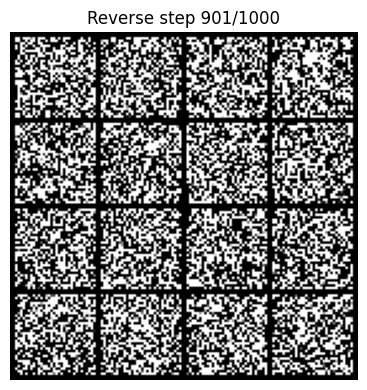

[reverse step 801/1000 | i=800 | t=0.8000]
mean=-0.7158, std=9.2052, min=-39.1405, max=39.5479
Time of last 100 steps: 7.065677642822266. Time remaining 141.3135528564453.



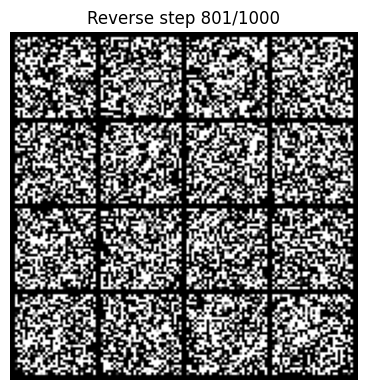

[reverse step 701/1000 | i=700 | t=0.7000]
mean=-0.7937, std=4.0448, min=-15.6613, max=16.1174
Time of last 100 steps: 6.930174350738525. Time remaining 207.90523052215576.



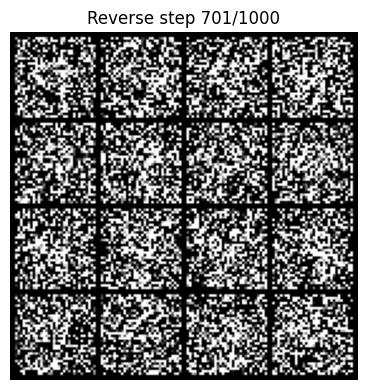

[reverse step 601/1000 | i=600 | t=0.6000]
mean=-0.7598, std=1.8489, min=-7.8815, max=6.9666
Time of last 100 steps: 6.871737718582153. Time remaining 274.86950874328613.



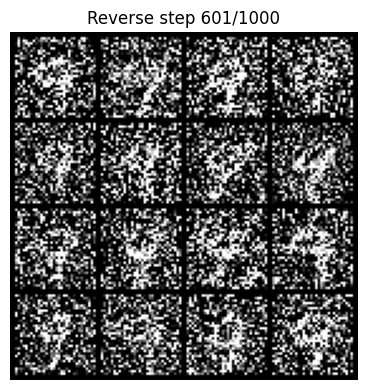

[reverse step 501/1000 | i=500 | t=0.5000]
mean=-0.7476, std=0.9383, min=-3.8822, max=3.5666
Time of last 100 steps: 6.916181564331055. Time remaining 345.80907821655273.



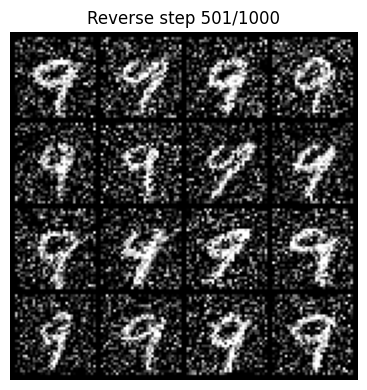

[reverse step 401/1000 | i=400 | t=0.4000]
mean=-0.7545, std=0.6379, min=-2.1334, max=2.0087
Time of last 100 steps: 6.934477806091309. Time remaining 416.0686683654785.



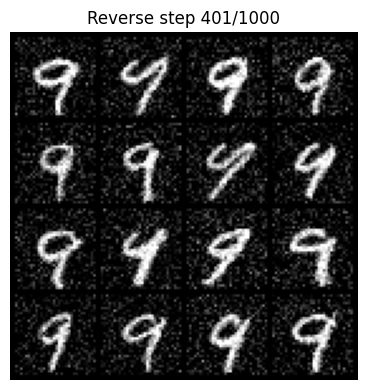

[reverse step 301/1000 | i=300 | t=0.3000]
mean=-0.7634, std=0.5628, min=-1.5165, max=1.4104
Time of last 100 steps: 6.875743389129639. Time remaining 481.3020372390747.



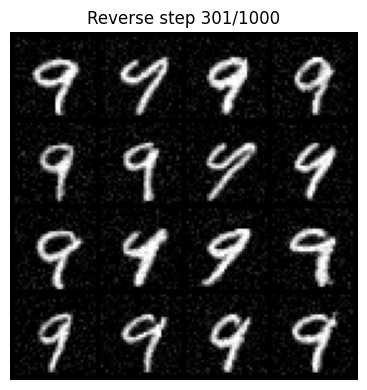

[reverse step 201/1000 | i=200 | t=0.2000]
mean=-0.7658, std=0.5478, min=-1.2091, max=1.1499
Time of last 100 steps: 6.914173364639282. Time remaining 553.1338691711426.



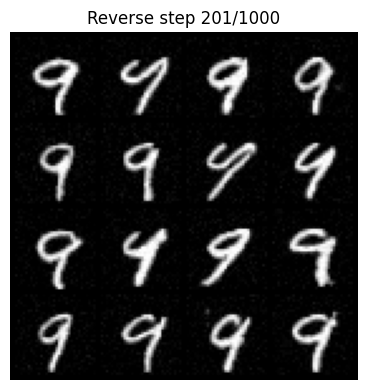

[reverse step 101/1000 | i=100 | t=0.1000]
mean=-0.7659, std=0.5447, min=-1.0944, max=1.0664
Time of last 100 steps: 6.928337097167969. Time remaining 623.5503387451172.



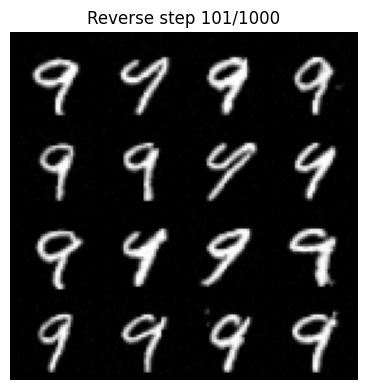

[reverse step 15/1000 | i=14 | t=0.0140]
mean=-0.7659, std=0.5441, min=-1.0444, max=1.0366
Time of last 100 steps: 5.952913284301758. Time remaining 589.338415145874.



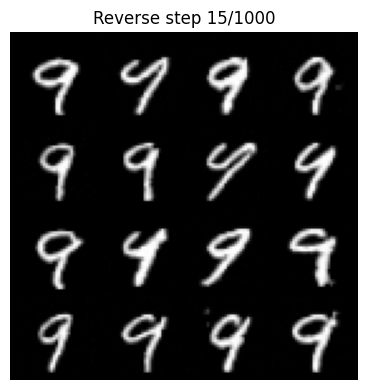

[reverse step 14/1000 | i=13 | t=0.0130]
mean=-0.7659, std=0.5441, min=-1.0455, max=1.0345
Time of last 100 steps: 0.10479855537414551. Time remaining 10.375056982040405.



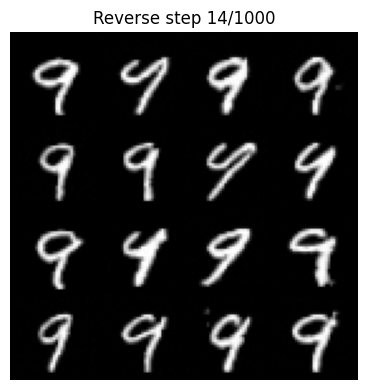

[reverse step 13/1000 | i=12 | t=0.0120]
mean=-0.7659, std=0.5440, min=-1.0448, max=1.0358
Time of last 100 steps: 0.10915350914001465. Time remaining 10.80619740486145.



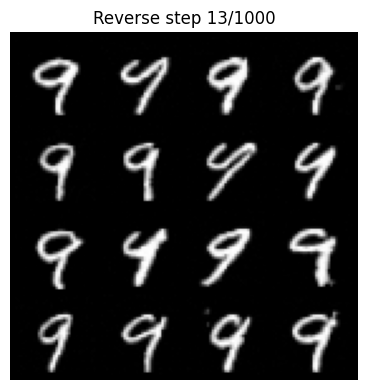

[reverse step 12/1000 | i=11 | t=0.0110]
mean=-0.7659, std=0.5440, min=-1.0442, max=1.0361
Time of last 100 steps: 0.11442232131958008. Time remaining 11.327809810638428.



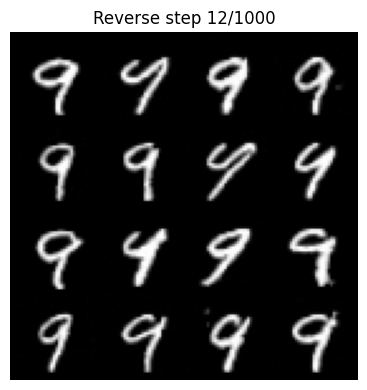

[reverse step 11/1000 | i=10 | t=0.0100]
mean=-0.7659, std=0.5440, min=-1.0455, max=1.0362
Time of last 100 steps: 0.1101069450378418. Time remaining 10.900587558746338.



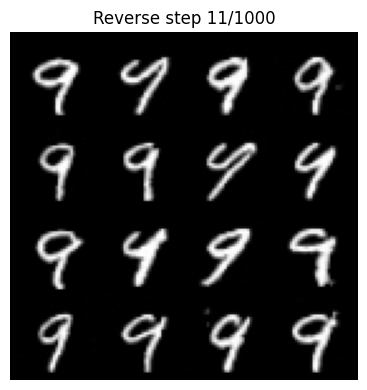

[reverse step 10/1000 | i=9 | t=0.0090]
mean=-0.7659, std=0.5440, min=-1.0450, max=1.0363
Time of last 100 steps: 0.10284066200256348. Time remaining 10.284066200256348.



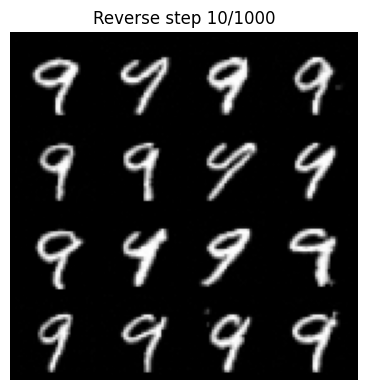

[reverse step 9/1000 | i=8 | t=0.0080]
mean=-0.7659, std=0.5440, min=-1.0457, max=1.0376
Time of last 100 steps: 0.10927677154541016. Time remaining 10.927677154541016.



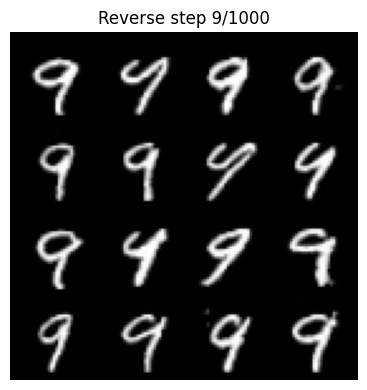

[reverse step 8/1000 | i=7 | t=0.0070]
mean=-0.7659, std=0.5440, min=-1.0473, max=1.0391
Time of last 100 steps: 0.10907769203186035. Time remaining 10.907769203186035.



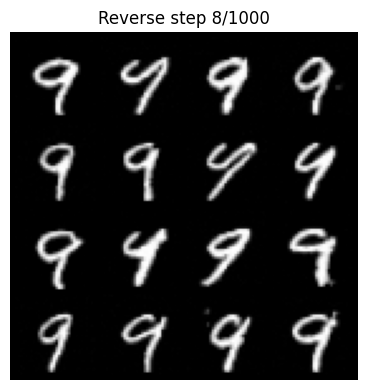

[reverse step 7/1000 | i=6 | t=0.0060]
mean=-0.7659, std=0.5440, min=-1.0482, max=1.0386
Time of last 100 steps: 0.10912466049194336. Time remaining 10.912466049194336.



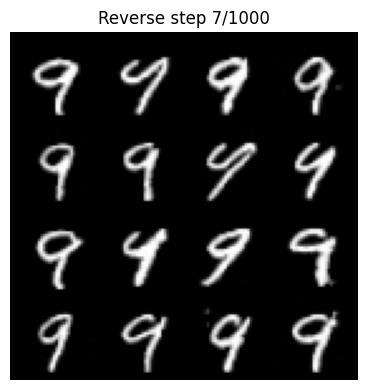

[reverse step 6/1000 | i=5 | t=0.0050]
mean=-0.7659, std=0.5440, min=-1.0480, max=1.0361
Time of last 100 steps: 0.09668374061584473. Time remaining 9.668374061584473.



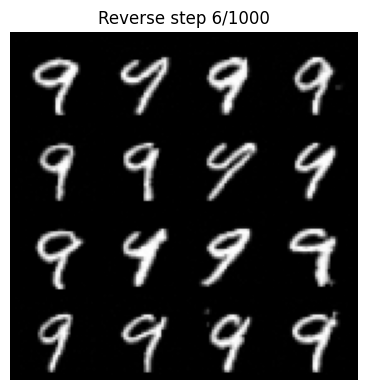

[reverse step 5/1000 | i=4 | t=0.0040]
mean=-0.7659, std=0.5440, min=-1.0470, max=1.0358
Time of last 100 steps: 0.10303759574890137. Time remaining 10.303759574890137.



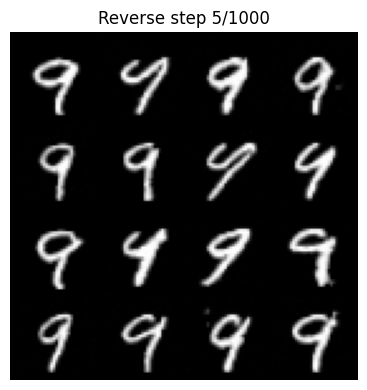

[reverse step 4/1000 | i=3 | t=0.0030]
mean=-0.7659, std=0.5440, min=-1.0462, max=1.0374
Time of last 100 steps: 0.12208414077758789. Time remaining 12.208414077758789.



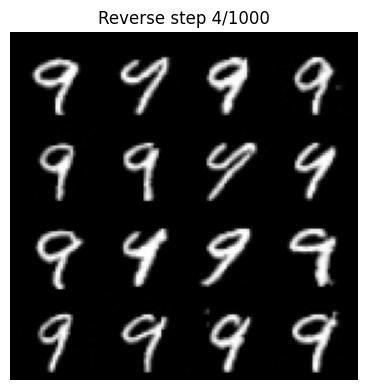

[reverse step 3/1000 | i=2 | t=0.0020]
mean=-0.7659, std=0.5440, min=-1.0461, max=1.0355
Time of last 100 steps: 0.11011314392089844. Time remaining 11.011314392089844.



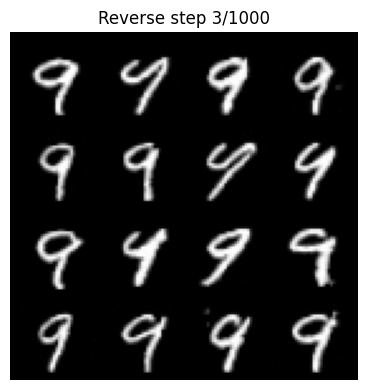

In [24]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
import wandb
batch_size = 16

test_labels = [9]

test_labels = torch.tensor(test_labels, device=device)

callback_fn = log_denoising_step_wandb
wandb.init(project="LDM_Testing", name=f"Sampling_WO_Scores_{weights_name}")

samples = diffusion.reverse_process(
    model=model_fn,             
    shape=(batch_size, 1, 32, 32),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device,
    labels = test_labels,              # Pass device explicitly
    ema_model = ema_model, 
    use_ema=False,
    caption="debug"
)
wandb.finish()

Grid salvata in: images/decoded_grid_steps_1000_LDM_final_T1000_LR00001_E40_SA_CFG_ts20260121_232516.pth_CFG_5.png


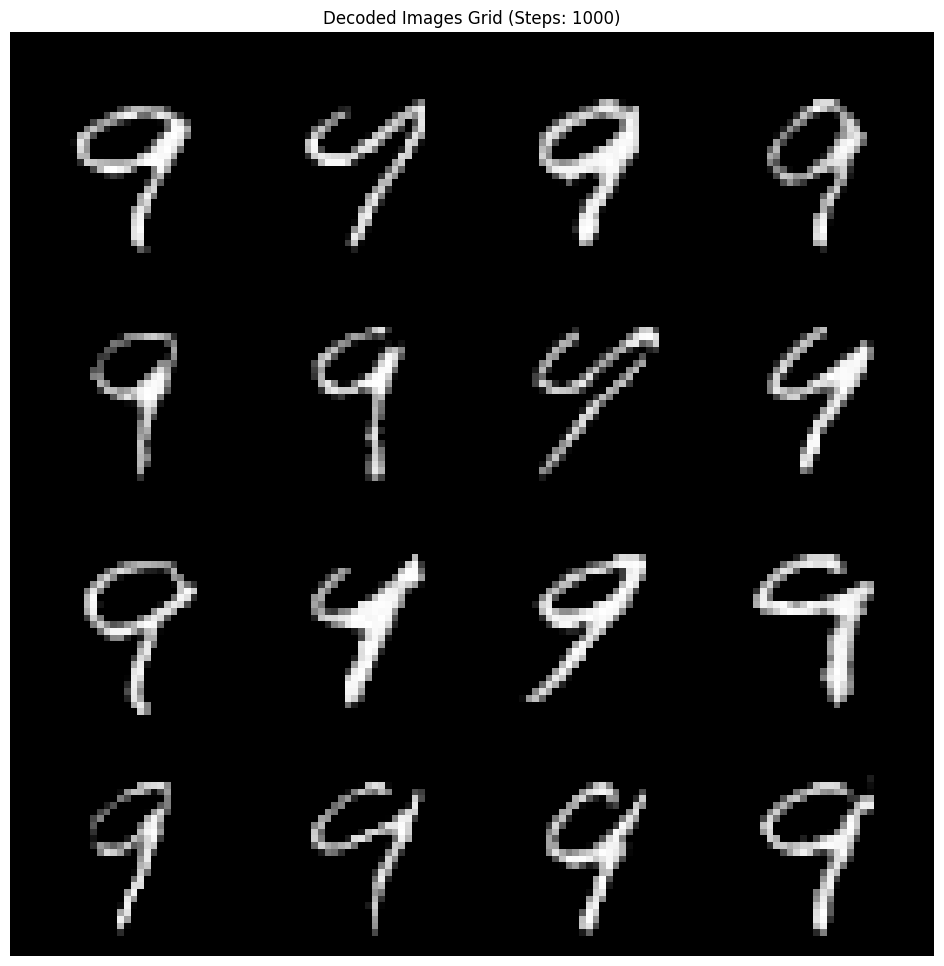

In [25]:

# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True, value_range=(0, 1))


# Salva la griglia
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")
# plt.show()
# 🔹 Salvataggio
save_path = f"images/decoded_grid_steps_{cfg['N']}_{weights_name}_CFG_{diffusion.guidance_scale}.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
print(f"Grid salvata in: {save_path}")